In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn.datasets

from sklearn.model_selection import train_test_split

from sklearn import metrics

import aed_funcoes as aed

In [2]:
house_price_dataset = sklearn.datasets.fetch_california_housing()
df = pd.DataFrame(house_price_dataset.data, columns = house_price_dataset.feature_names)
df["preco_casa"] = house_price_dataset["target"]
df.columns = ["renda_mediana_bloco", "idade_casa", "media_salas_bloco", "media_quartos_bloco", "populacao_bloco", "pessoas_por_residencia_bloco", "latitude", "longitude", "preco_casa"]

df = df.loc[df["preco_casa"] < 5.0]

np.random.seed(10)
# df_sample = df.iloc[np.random.choice(np.arange(df.shape[0]+1), size = 10000),:].reset_index(drop = True)
df_sample = df.copy()

df_sample.head()

,renda_mediana_bloco,idade_casa,media_salas_bloco,media_quartos_bloco,populacao_bloco,pessoas_por_residencia_bloco,latitude,longitude,preco_casa
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


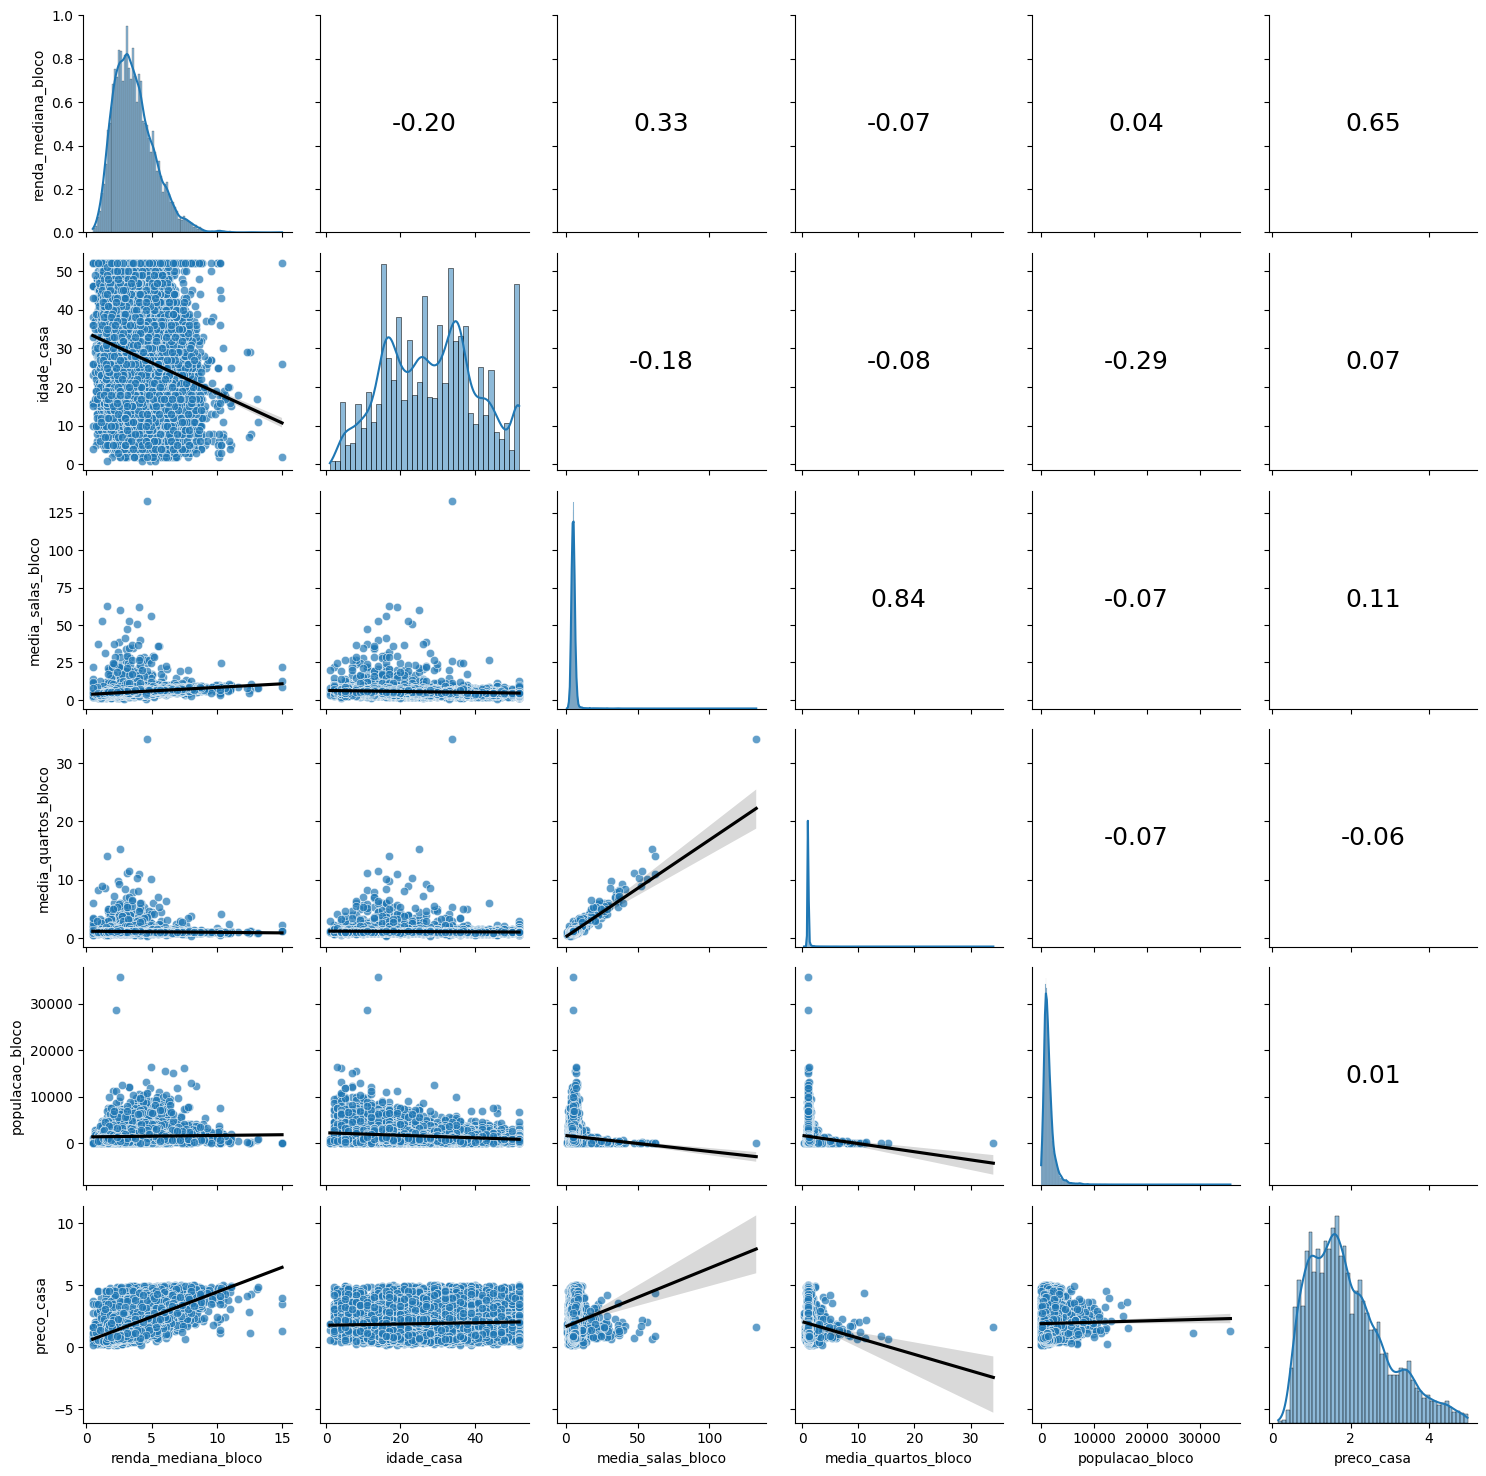

In [3]:
aed.pair_plot(df_sample, variables = ["renda_mediana_bloco", "idade_casa", "media_salas_bloco", "media_quartos_bloco", "populacao_bloco", "preco_casa"])

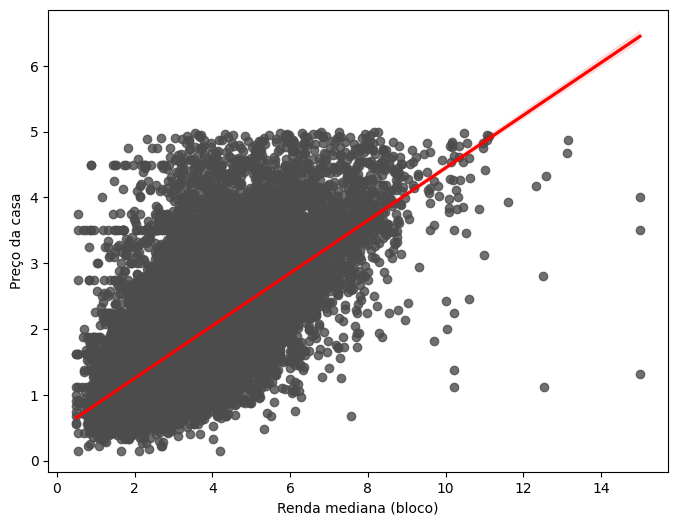

In [4]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.regplot(x = "renda_mediana_bloco", y = "preco_casa", data = df_sample, ci = 95, marker = "o", color = ".3", line_kws = dict(color = "r"), ax = ax)

ax.set_xlabel("Renda mediana (bloco)")
ax.set_ylabel("Preço da casa")

plt.show()

In [5]:
df_model = df_sample.loc[:, ["renda_mediana_bloco", "idade_casa", "media_salas_bloco", "media_quartos_bloco", "populacao_bloco", "pessoas_por_residencia_bloco"]]
target = df_sample["preco_casa"]
df_model.head()

,renda_mediana_bloco,idade_casa,media_salas_bloco,media_quartos_bloco,populacao_bloco,pessoas_por_residencia_bloco
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467


In [28]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

df_train, df_test, target_train, target_test = train_test_split(df_model, target, test_size = 0.3, random_state = 10)

df_train = df_train.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)
target_train = target_train.reset_index(drop = True)
target_test = target_test.reset_index(drop = True)

y_train = target_train
y_test = target_test

# Adiciona o intercepto nos dados
X_train_sm = sm.add_constant(df_train)
X_test_sm = sm.add_constant(df_test)

# Treina o modelo OLS
modelo_sm = sm.OLS(y_train, X_train_sm)
resultados = modelo_sm.fit()

print("Estimativa da variância: {}".format(resultados.scale))

Estimativa da variância: 0.46899518119112427


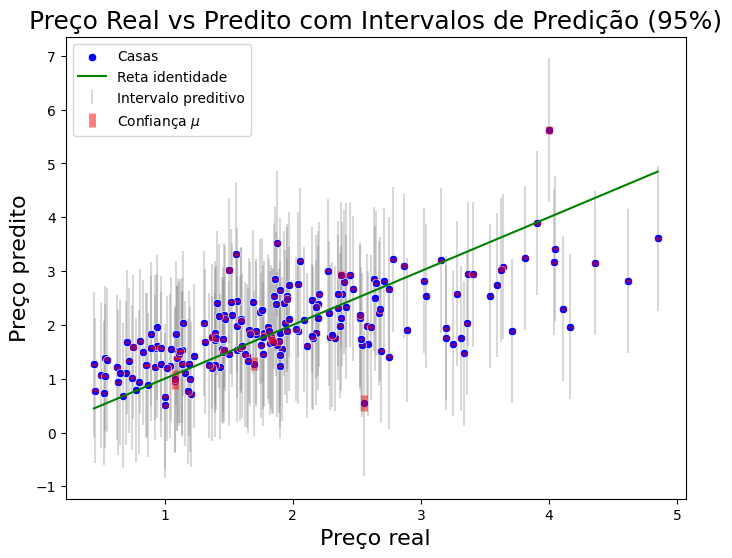

In [52]:
np.random.seed(10)
sample_size = 200
plot_sample = np.random.choice(np.arange(X_test_sm.shape[0]), size = sample_size, replace = False)

X_test_sample = X_test_sm.iloc[plot_sample,:]
y_test_sample = y_test[plot_sample]

# Predições para o conjunto de teste
predicoes = resultados.get_prediction(X_test_sample)

# Extrair um DataFrame com as métricas preditas
df_previsoes = predicoes.summary_frame(alpha = 0.05)

# O valor predito e os limites do intervalo de predição
y_test_pred_sample = df_previsoes['mean']
limite_inferior = df_previsoes['obs_ci_lower']
limite_superior = df_previsoes['obs_ci_upper']

# Calcular a margem de erro (distância do valor predito até o limite)
margem_erro = limite_superior - y_test_pred_sample

limite_inferior_mu = df_previsoes['mean_ci_lower']
limite_superior_mu = df_previsoes['mean_ci_upper']

margem_erro_mu = limite_superior_mu - y_test_pred_sample

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

# zorder=1 garante que fiquem atrás dos pontos
ax.errorbar(
    x = y_test_sample, 
    y = y_test_pred_sample, 
    yerr = margem_erro,
    fmt = 'none',       # 'none' para não desenhar pontos ou linhas entre eles, apenas as barras
    ecolor = 'gray',    # cor das barras
    alpha = 0.3,
    zorder = 1,
    label = r"Intervalo preditivo"
)

ax.errorbar(
    x = y_test_sample, 
    y = y_test_pred_sample, 
    yerr = margem_erro_mu, 
    fmt = 'none',       # 'none' para não desenhar pontos ou linhas entre eles, apenas as barras
    ecolor = 'red',    # cor das barras
    alpha = 0.5,
    zorder = 2,
    linewidth = 5,
    label = r"Confiança $\mu$"
)

# Plotar os pontos por cima das barras
sns.scatterplot(x = y_test_sample, y = y_test_pred_sample, ax = ax, color = 'blue', zorder = 1, label = "Casas")

# Linha de referência (ideal) - Ajustada dinamicamente para os limites dos dados reais
limite_min = min(y_test_sample.min(), y_test_sample.min())
limite_max = max(y_test_sample.max(), y_test_sample.max())
ax.plot([limite_min, limite_max], [limite_min, limite_max], color="green", zorder=3, label = "Reta identidade")

ax.set_xlabel("Preço real", fontsize = 16)
ax.set_ylabel("Preço predito", fontsize = 16)
ax.set_title("Preço Real vs Predito com Intervalos de Predição (95%)", fontsize = 18)

ax.legend(loc = "upper left")

plt.show()

In [8]:
from silence_tensorflow import silence_tensorflow
silence_tensorflow()
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

import thetaflow as thf
print("Thetaflow version: {}".format(thf.__version__))

E0000 00:00:1790880327.149239   16945 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1790880327.154557   16945 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1790880327.168326   16945 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1790880327.168351   16945 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1790880327.168354   16945 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1790880327.168357   16945 computation_placer.cc:177] computation placer already registered. Please check linka

Thetaflow version: 0.0.38


I0000 00:00:1790880330.237038   16945 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4392 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5


In [9]:
raw_nn_parameters = {
    "y_pred": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": 2.5}
}

def raw_nn_loss(model, nn_output, data):
    X, y = data

    y_pred = model.get_variable("y_pred", nn_output)

    # Mean squared error
    return tf.reduce_mean( (y - y_pred)**2 )

def raw_nn_neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    model.dense1 = keras.layers.Dense(units = 16, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense2 = keras.layers.Dense(units = 8, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense2")
    model.dense3 = keras.layers.Dense(units = 4, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense3")
    model.dense4 = keras.layers.Dense(units = 1, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = True, name = "output")

def raw_nn_network_call(model, x_input, training = False):
    x = model.dense1(x_input)
    x = model.dense2(x)
    x = model.dense3(x)
    return model.dense4(x)

def raw_nn_network_call_nolast(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    x = model.dense3(x)
    return x

In [10]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

with tf.device("/CPU:0"):
    raw_nn_model = thf.ModelNN(raw_nn_parameters, raw_nn_loss,
                                   raw_nn_neural_network, raw_nn_network_call, raw_nn_network_call_nolast,
                                   input_dim = (df_train.shape[1], ), seed = 10)
    data_train = [y_train]
    x_scaled_train = sc.fit_transform(df_train)
    x_scaled_test = sc.transform(df_test)
    raw_nn_model.pre_train_model(epochs = 500, x = x_scaled_train, data = data_train)
    raw_nn_model.train_model(epochs = 15000, x = x_scaled_train, data = data_train,
                       shuffle = True,
                       validation = True, val_prop = 0.2,
                       fine_tune = False, get_covariances = False,
                       optimizer_independent = optimizers.Adam(learning_rate = 0.05),
                       optimizer_nn = optimizers.Adam(learning_rate = 0.05),
                       train_batch_size = None, val_batch_size = None,
                       buffer_size = 4096, gradient_accumulation_steps = None,
                       early_stopping = True, early_stopping_warmup = 50, early_stopping_patience = 10,
                       reduce_lr = True, reduce_lr_warmup = 10,
                       reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 5,
                       reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-4,
                       verbose = 1, print_freq = 1)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 279 / 15000 ]  | Avg. Train NLL:  2.96924063e-05 | Avg. Validation NLL:  0.000121729325 | Best Avg. Validation NLL:  0.000121604528 | Speed:  0.00603192439  epoch/s    | Elapsed Time:  1.68290687  s    
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 280 / 15000 ]  | Avg. Train NLL:  2.9690229e-05 | Avg. Validation NLL:  0.000121729478 | Best Avg. Validation NLL:  0.000121604528 | Speed:  0.00603460241  epoch/s    | Elapsed Time:  1.68968868  s   Restoring best weights...

Done.
Optimization finished in 8.480 seconds.


In [53]:
df_test_sample

,renda_mediana_bloco,idade_casa,media_salas_bloco,media_quartos_bloco,populacao_bloco,pessoas_por_residencia_bloco
3637,1.2024,36.0,5.749035,1.277992,838.0,3.235521
4129,2.7386,12.0,5.305160,1.220641,3015.0,2.682384
5863,5.6205,19.0,7.232301,1.068584,1383.0,3.059735
2747,3.7477,8.0,5.227139,1.019174,2118.0,3.123894
5448,6.0715,24.0,6.782051,0.948718,676.0,2.888889
...,...,...,...,...,...,...
760,5.1330,17.0,6.334501,1.045534,1176.0,2.059545
2192,4.3424,43.0,5.261780,1.041885,723.0,3.785340
829,4.6845,20.0,5.187323,1.020814,2892.0,2.736045
2294,2.2449,30.0,7.508039,1.167203,1214.0,3.903537


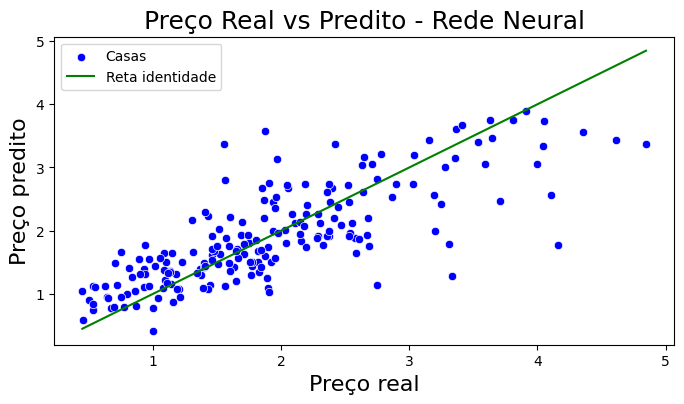

In [54]:
df_test_sample = df_test.iloc[plot_sample,:]
y_test_sample = y_test[plot_sample]

x_scaled_test_sample = sc.transform( df_test_sample )

y_test_pred_nn_sample = raw_nn_model.predict(x_scaled_test_sample)["y_pred"].numpy().flatten()

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,4))

sns.scatterplot(x = y_test_sample, y = y_test_pred_nn_sample, ax = ax, color = 'blue', zorder = 2, label = "Casas")

ax.plot([limite_min, limite_max], [limite_min, limite_max], color="green", zorder=3, label = "Reta identidade")

ax.set_xlabel("Preço real", fontsize = 16)
ax.set_ylabel("Preço predito", fontsize = 16)
ax.set_title("Preço Real vs Predito - Rede Neural", fontsize = 18)

ax.legend(loc = "upper left")

plt.show()

In [55]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error

# Predições para o conjunto de teste
predicoes = resultados.get_prediction(X_test_sm)
df_previsoes = predicoes.summary_frame(alpha = 0.05)
y_test_pred = df_previsoes['mean']

y_test_pred_nn = raw_nn_model.predict(x_scaled_test)["y_pred"].numpy().flatten()

mse_linear = root_mean_squared_error(y_test, y_test_pred)
mse_nn = root_mean_squared_error(y_test, y_test_pred_nn)

print("RMSE Linear model: {}".format(mse_linear))
print("RMSE Neural Network model: {}".format(mse_nn))

RMSE Linear model: 0.6947600009232957
RMSE Neural Network model: 0.5905645852550155


In [16]:
regression_nn_parameters = {
    "mu": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": 2.5},
    "sigma2": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "independent", "shape": 1, "init": 1.0}
}

def regression_nn_loss(model, nn_output, data):
    X, y = data
    mu = model.get_variable("mu", nn_output)
    sigma2 = model.get_variable("sigma2")
    eps = tf.constant(1.0e-7, dtype = tf.float32)
    loglik = tf.reduce_sum( -1/2 * tf.math.log(sigma2 + eps) - (y - mu)**2 / (2 * sigma2) )
    return -loglik

def regression_nn_neural_network(model, seed = None):
    initializer = initializers.GlorotNormal(seed = seed)
    model.dense1 = keras.layers.Dense(units = 16, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense1")
    model.dense2 = keras.layers.Dense(units = 8, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense2")
    model.dense3 = keras.layers.Dense(units = 4, activation = "gelu", kernel_initializer = initializer, dtype = tf.float32, name = "dense3")
    model.dense4 = keras.layers.Dense(units = 1, kernel_initializer = initializer, dtype = tf.float32, activation = None, use_bias = True, name = "output")

def regression_nn_network_call(model, x_input, training = False):
    x = model.dense1(x_input)
    x = model.dense2(x)
    x = model.dense3(x)
    return model.dense4(x)

def regression_nn_network_call_nolast(model, x_input):
    x = model.dense1(x_input)
    x = model.dense2(x)
    x = model.dense3(x)
    return x

In [20]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

with tf.device("/CPU:0"):
    regression_nn_model = thf.ModelNN(regression_nn_parameters, regression_nn_loss,
                                      raw_nn_neural_network, raw_nn_network_call, raw_nn_network_call_nolast,
                                      input_dim = (df_train.shape[1], ), seed = 10)
    data_train = [y_train]
    x_scaled_train = sc.fit_transform(df_train)
    x_scaled_test = sc.transform(df_test)
    regression_nn_model.pre_train_model(epochs = 500, x = x_scaled_train, data = data_train)
    regression_nn_model.train_model(epochs = 15000, x = x_scaled_train, data = data_train,
                                 shuffle = True,
                                 validation = True, val_prop = 0.2,
                                 optimizer_independent = optimizers.Adam(learning_rate = 0.05),
                                 optimizer_nn = optimizers.Adam(learning_rate = 0.05),
                                 train_batch_size = None, val_batch_size = None,
                                 buffer_size = 4096, gradient_accumulation_steps = None,
                                 early_stopping = True, early_stopping_warmup = 50, early_stopping_patience = 10,
                                 reduce_lr = True, reduce_lr_warmup = 10,
                                 reduce_lr_factor = 0.5, reduce_lr_min_delta = 0.0, reduce_lr_patience = 5,
                                 reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-4,
                                 verbose = 1, print_freq = 1)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 234 / 15000 ]  | Avg. Train NLL:  -0.0663864166 | Avg. Validation NLL:  -0.0501065478 | Best Avg. Validation NLL:  -0.0502551645 | Speed:  0.00627099164  epoch/s    | Elapsed Time:  1.46741199  s        
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 235 / 15000 ]  | Avg. Train NLL:  -0.0663974 | Avg. Validation NLL:  -0.0502140261 | Best Avg. Validation NLL:  -0.0502551645 | Speed:  0.00626897113  epoch/s    | Elapsed Time:  1.47320819  s   Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 69 / 15000 ]  | Avg. Train NLL:  -0.0659774467 | Best Avg. Train NLL:  -0.0659774467 | Avg. Validation NLL:  -0.0500015691 | Speed:  0.00372584653  epoch/s    | Elapsed Time:  0.257083416  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 5

In [22]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error

# Predições para o conjunto de teste
predicoes = resultados.get_prediction(X_test_sm)
df_previsoes = predicoes.summary_frame(alpha = 0.05)
y_test_pred = df_previsoes['mean']

y_test_pred_nn = raw_nn_model.predict(x_scaled_test)["y_pred"].numpy().flatten()
y_test_pred_regression_nn = regression_nn_model.predict(x_scaled_test)["mu"].numpy().flatten()

mse_linear = root_mean_squared_error(y_test, y_test_pred)
mse_nn = root_mean_squared_error(y_test, y_test_pred_nn)
mse_regression_nn = root_mean_squared_error(y_test, y_test_pred_regression_nn)

print("MSE Linear model: {}".format(mse_linear))
print("MSE Neural Network model: {}".format(mse_nn))
print("MSE Regression Neural Network model: {}".format(mse_nn))

MSE Linear model: 0.6947600009232957
MSE Neural Network model: 0.5905645852550155
MSE Regression Neural Network model: 0.5905645852550155


In [57]:
np.sqrt(regression_nn_model.predict("sigma2"))

array([0.5677938], dtype=float32)

# Voltar aqui! Fazer o gráfico com as predições intervalares com o modelo de redes neurais

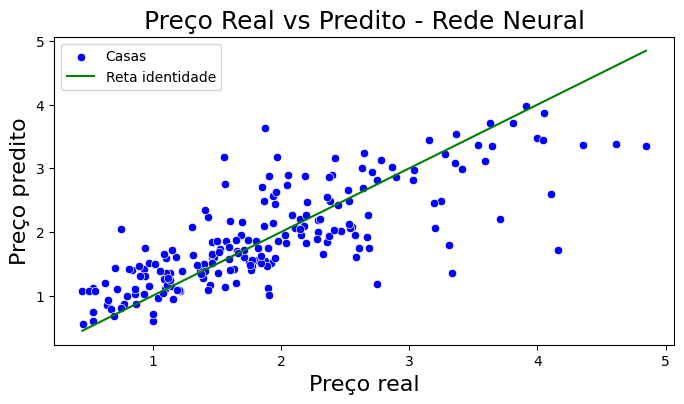

In [64]:
# np.random.seed(10)
# sample_size = 200
# plot_sample = np.random.choice(np.arange(X_test_sm.shape[0]), size = sample_size, replace = False)



# X_test_sample = df_test.iloc[plot_sample,:]
# y_test_sample = y_test[plot_sample]

# # Predições para o conjunto de teste
# predicoes = resultados.get_prediction(X_test_sample)

# # Extrair um DataFrame com as métricas preditas
# df_previsoes = predicoes.summary_frame(alpha = 0.05)

# # O valor predito e os limites do intervalo de predição
# y_test_pred_sample = df_previsoes['mean']
# limite_inferior = df_previsoes['obs_ci_lower']
# limite_superior = df_previsoes['obs_ci_upper']

# # Calcular a margem de erro (distância do valor predito até o limite)
# margem_erro = limite_superior - y_test_pred_sample

# limite_inferior_mu = df_previsoes['mean_ci_lower']
# limite_superior_mu = df_previsoes['mean_ci_upper']

# margem_erro_mu = limite_superior_mu - y_test_pred_sample

# fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

# # zorder=1 garante que fiquem atrás dos pontos
# ax.errorbar(
#     x = y_test_sample, 
#     y = y_test_pred_sample, 
#     yerr = margem_erro,
#     fmt = 'none',       # 'none' para não desenhar pontos ou linhas entre eles, apenas as barras
#     ecolor = 'gray',    # cor das barras
#     alpha = 0.3,
#     zorder = 1,
#     label = r"Intervalo preditivo"
# )

# ax.errorbar(
#     x = y_test_sample, 
#     y = y_test_pred_sample, 
#     yerr = margem_erro_mu, 
#     fmt = 'none',       # 'none' para não desenhar pontos ou linhas entre eles, apenas as barras
#     ecolor = 'red',    # cor das barras
#     alpha = 0.5,
#     zorder = 2,
#     linewidth = 5,
#     label = r"Confiança $\mu$"
# )

df_test_sample = df_test.iloc[plot_sample,:]
y_test_sample = y_test[plot_sample]

x_scaled_test_sample = sc.transform( df_test_sample )

y_test_pred_regression_nn_sample = regression_nn_model.predict(x_scaled_test_sample)["mu"].numpy().flatten()

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,4))

sns.scatterplot(x = y_test_sample, y = y_test_pred_nn_sample, ax = ax, color = 'blue', zorder = 2, label = "Casas")

ax.plot([limite_min, limite_max], [limite_min, limite_max], color="green", zorder=3, label = "Reta identidade")

ax.set_xlabel("Preço real", fontsize = 16)
ax.set_ylabel("Preço predito", fontsize = 16)
ax.set_title("Preço Real vs Predito - Rede Neural", fontsize = 18)

ax.legend(loc = "upper left")

plt.show()